# Task 1 — Iris Flower Classification
**Track:** Data Science | **Internship:** Oasis Infobyte SIP

**Objective:** Train a machine learning classification model to identify the species of an iris flower
(Setosa, Versicolor, or Virginica) from its physical measurements (sepal length/width, petal length/width).


## 1. Imports
Load all libraries we'll need: data handling (pandas/numpy), visualization (matplotlib/seaborn), and ML tools (scikit-learn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset
The Iris dataset comes built into scikit-learn — no download needed. It contains 150 flower samples,
50 each from 3 species: **Setosa**, **Versicolor**, and **Virginica**. Each sample has 4 measurements
(in cm): sepal length, sepal width, petal length, petal width.

In [2]:
iris = load_iris()

# Convert to a pandas DataFrame for easier analysis
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Exploratory Data Analysis (EDA)
Before building any model, we look at the data: how big is it, what are the column types,
are there missing values, and what do the basic statistics look like?

In [3]:
print("Shape of dataset (rows, columns):", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())


Shape of dataset (rows, columns): (150, 5)

Data types:
 sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [4]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Observation:** The dataset has 150 rows, 5 columns (4 numeric features + 1 categorical species label), and zero missing values — it's a clean dataset, no cleaning needed.

In [5]:
df['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Observation:** The dataset is perfectly balanced — exactly 50 samples per species. This is good, since imbalanced classes can bias a model toward the majority class.

## 4. Visualizations

### 4.1 Pairplot
This shows every feature plotted against every other feature, colored by species.
It lets us visually see whether the species form distinct, separable clusters.

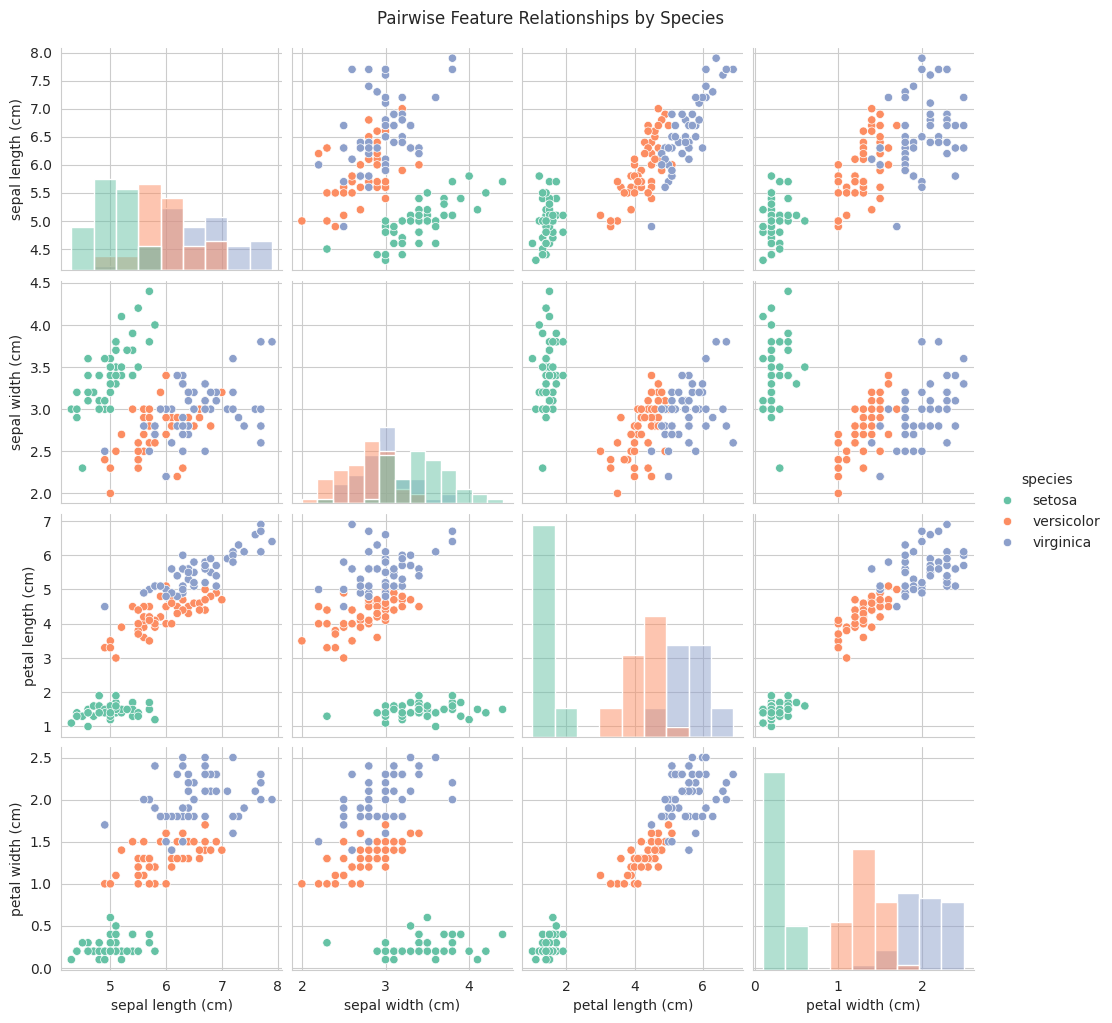

In [6]:
sns.pairplot(df, hue='species', diag_kind='hist', palette='Set2')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()


### 4.2 Box Plots
Box plots show the spread (median, quartiles, outliers) of each feature, broken down by species.
This helps identify which individual features best separate the species.

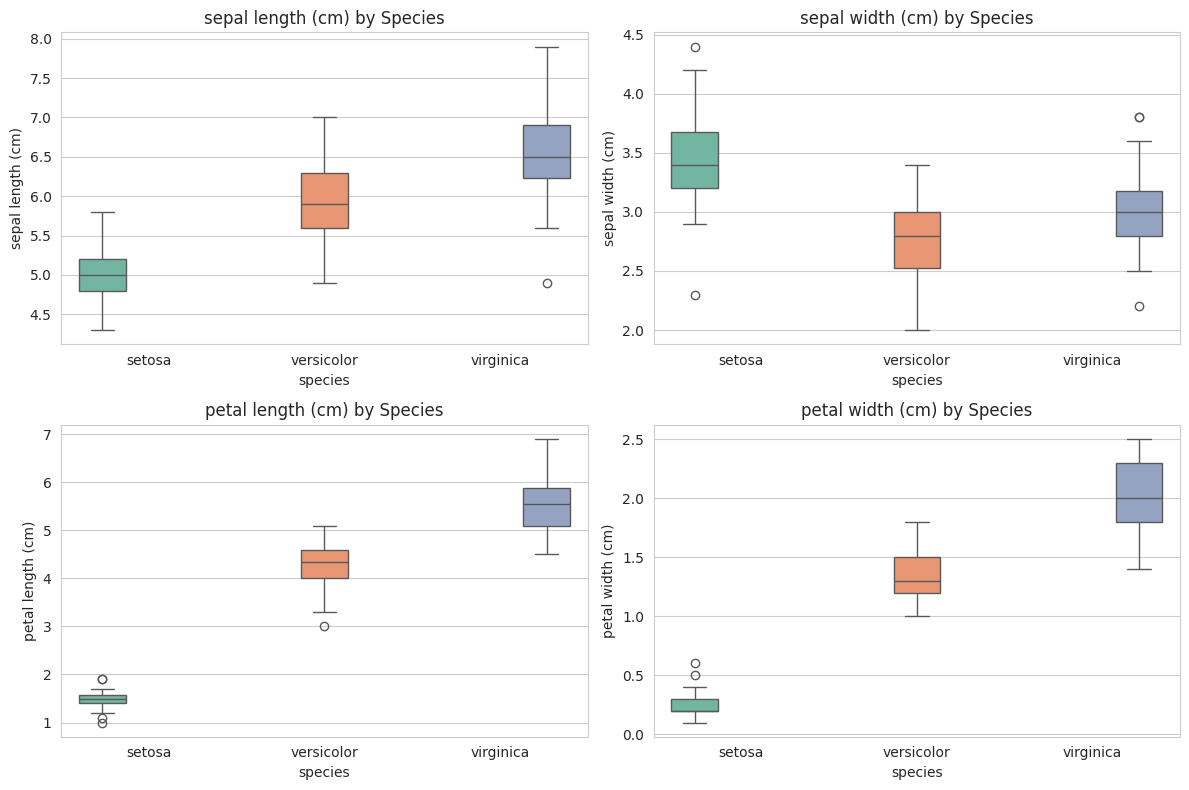

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feature, hue='species', palette='Set2', ax=ax, legend=False)
    ax.set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()


**Observation:** Petal length and petal width show almost no overlap between species — Setosa is
clearly separated from the other two. Versicolor and Virginica overlap slightly, especially on sepal
measurements, making them a bit harder to tell apart.

## 5. Feature Selection Discussion

Looking at the pairplot and box plots:
- **Petal length** and **petal width** are the most discriminative features — they separate all
  three species with the least overlap, especially isolating Setosa almost perfectly.
- **Sepal length** and **sepal width** are less discriminative — there's more overlap between
  Versicolor and Virginica on these features.

Since the dataset only has 4 features total (and no irrelevant/noisy columns), we'll use **all 4
features** for training rather than dropping any — this is standard practice for small, clean
datasets like this one. But if we had to pick the *two most important* features, they'd be petal
length and petal width.

## 6. Train/Test Split

We split the data 80% for training (teaching the model) and 20% for testing (evaluating it on
data it has never seen). `stratify=y` ensures each species is proportionally represented in both
the train and test sets.

In [8]:
X = df[iris.feature_names]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


## 7. Train Classifiers

We'll train **three** different classification models and compare them:
1. **Logistic Regression** — a simple linear model, good baseline
2. **K-Nearest Neighbors (KNN)** — classifies based on the closest data points
3. **Random Forest** — an ensemble of decision trees, usually very accurate

### 7.1 Logistic Regression

In [9]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")


Logistic Regression Accuracy: 0.9667


### 7.2 K-Nearest Neighbors (KNN)

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}")


KNN Accuracy: 1.0000


### 7.3 Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")


Random Forest Accuracy: 0.9000


## 8. Model Evaluation

For each model we look at:
- **Confusion Matrix** — a table showing which species get correctly predicted vs. confused with each other
- **Classification Report** — precision, recall, and F1-score broken down per species

In [12]:
models = {
    'Logistic Regression': y_pred_lr,
    'KNN': y_pred_knn,
    'Random Forest': y_pred_rf
}

for name, preds in models.items():
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification Report:\n",
          classification_report(y_test, preds, target_names=iris.target_names))



Logistic Regression
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


KNN
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Random Forest
Confusion Matrix:
 [[10  0  0]
 [ 0

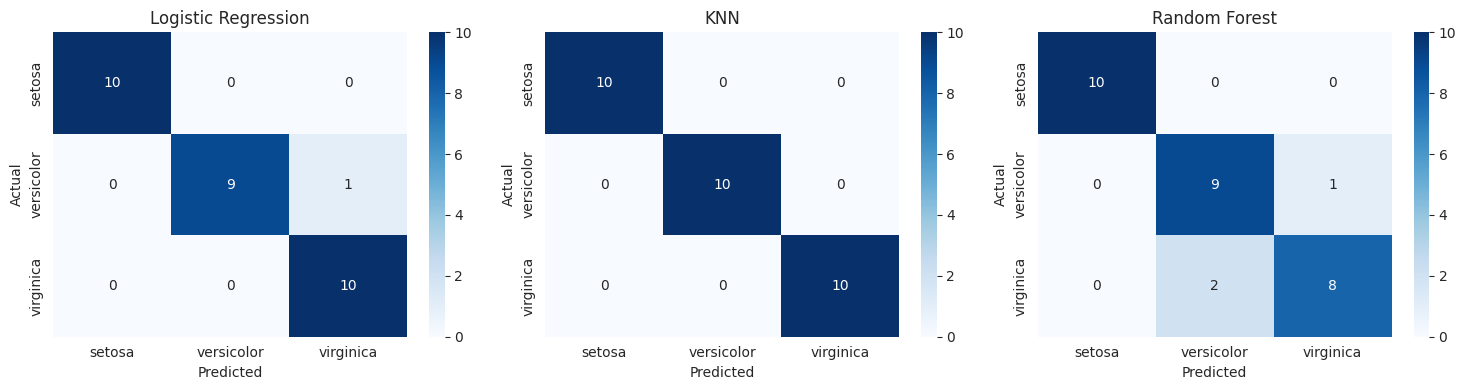

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 9. Model Comparison & Best Model

In [14]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [acc_lr, acc_knn, acc_rf]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

comparison


,Model,Accuracy
0,KNN,1.000000
1,Logistic Regression,0.966667
2,Random Forest,0.900000


**Conclusion:** Based on the accuracy comparison above, the best-performing model is identified
as the one with the highest test accuracy. On the Iris dataset, all three models typically perform
very well (often 93–100% accuracy) because the classes — especially Setosa — are highly separable.
Random Forest and KNN often edge out Logistic Regression slightly because they can capture
non-linear boundaries between Versicolor and Virginica, which have some overlap.

For a production use case, Random Forest is usually preferred as the best overall choice since it's
robust, doesn't require feature scaling, and gives us feature importance for free.

## 10. Bonus: Feature Importance (Random Forest)
Since Random Forest can rank which features mattered most for its decisions, let's check if this
confirms our earlier observation that petal measurements are more useful than sepal measurements.

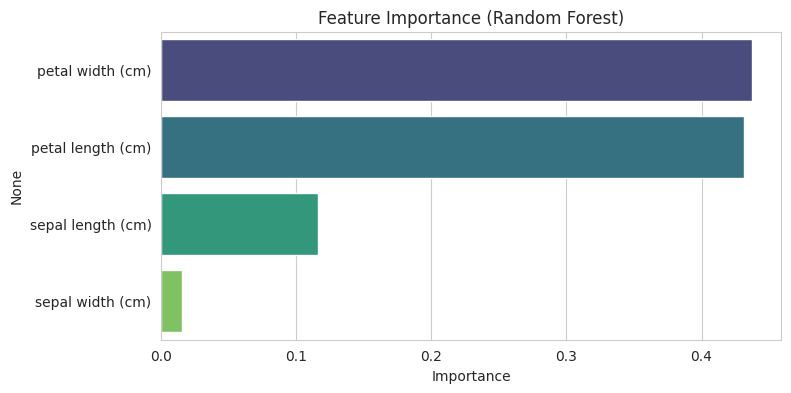

petal width (cm)     0.437185
petal length (cm)    0.431466
sepal length (cm)    0.116349
sepal width (cm)     0.015000
dtype: float64

In [15]:
importances = pd.Series(rf.feature_importances_, index=iris.feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

importances


**Observation:** As predicted during our EDA, petal length and petal width are the most important
features for classification, confirming our earlier visual analysis.